# YZTA Datathon — v9.1 



In [1]:
# HÜCRE 1 — Kurulum
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'lightgbm', 'catboost', 'xgboost', '-q'],
    capture_output=True
)

import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool

warnings.filterwarnings('ignore')
SEED    = 42
N_FOLDS = 5
np.random.seed(SEED)
print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


In [2]:
# HÜCRE 2 — Veri Yükleme + NaN Bayrakları

train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test_x.csv')

test_id = test_raw['id'].copy()
target  = train_raw['bilissel_performans_skoru'].copy()

TARGET_P1  = target.quantile(0.01)
TARGET_P99 = target.quantile(0.99)

print(f'Train: {train_raw.shape} | Test: {test_raw.shape}')
print(f'Target — Min:{target.min():.2f}  Max:{target.max():.2f}  '
      f'Ort:{target.mean():.2f}  Std:{target.std():.2f}')
print(f'Clip: [{TARGET_P1:.4f}, {TARGET_P99:.4f}]')

# NaN bayrakları — encoding öncesi ham veriden çıkar
NAN_FLAG_COLS = ['stres_skoru', 'yas', 'vucut_kitle_indeksi',
                 'gunluk_adim_sayisi']

train_nan = pd.DataFrame()
test_nan  = pd.DataFrame()
for col in NAN_FLAG_COLS:
    if col in train_raw.columns:
        train_nan[f'{col}_nan'] = train_raw[col].isna().astype(int)
        test_nan[f'{col}_nan']  = test_raw[col].isna().astype(int)
        n = train_raw[col].isna().sum()
        if n > 0:
            print(f'  {col}: {n} NaN bulundu')

print(f'NaN flag sütunları: {list(train_nan.columns)}')

Train: (56000, 24) | Test: (24000, 23)
Target — Min:0.00  Max:10.00  Ort:5.91  Std:2.23
Clip: [0.3328, 10.0000]
  stres_skoru: 1715 NaN bulundu
  vucut_kitle_indeksi: 1752 NaN bulundu
NaN flag sütunları: ['stres_skoru_nan', 'yas_nan', 'vucut_kitle_indeksi_nan', 'gunluk_adim_sayisi_nan']


In [17]:
# HÜCRE 3 — Temizlik & Encoding

# İKİ ayrı DataFrame tutulur:
#   train / test       → LGB + XGB için (target encoded kategorikler)
#   train_c / test_c   → CatBoost için (ham string kategorikler)

train = train_raw.drop(columns=['id', 'bilissel_performans_skoru']).copy()
test  = test_raw.drop(columns=['id']).copy()

ulke_mapping   = {'spain':'ispanya', 'south korea':'guney kore', 'sweden':'isvec',
                  'netherlands':'hollanda', 'mexico':'meksika', 'china':'cin'}
meslek_mapping = {'lawyer': 'avukat'}

cat_cols = train.select_dtypes(include='object').columns.tolist()
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in cat_cols:
    train[col] = train[col].fillna('bilinmiyor').astype(str).str.lower().str.strip()
    test[col]  = test[col].fillna('bilinmiyor').astype(str).str.lower().str.strip()

train['ulke']   = train['ulke'].replace(ulke_mapping)
test['ulke']    = test['ulke'].replace(ulke_mapping)
train['meslek'] = train['meslek'].replace(meslek_mapping)
test['meslek']  = test['meslek'].replace(meslek_mapping)

# CatBoost kopyası — ham kategorikler korunuyor (sayısal fill sonrası)
train_c = train.copy()
test_c  = test.copy()

# Sayısal eksikler: medyan
for col in num_cols:
    med        = train[col].median()
    train[col] = train[col].fillna(med)
    test[col]  = test[col].fillna(med)
    train_c[col] = train_c[col].fillna(med)
    test_c[col]  = test_c[col].fillna(med)

# Aykırı değer clip
''' for col in num_cols:
    lo, hi = train[col].quantile(0.01), train[col].quantile(0.99)
    train[col]   = train[col].clip(lo, hi)
    test[col]    = test[col].clip(lo, hi)
    train_c[col] = train_c[col].clip(lo, hi)
    test_c[col]  = test_c[col].clip(lo, hi) '''

# Binary encoding (ikisi için de)
for col in ['cinsiyet', 'gun_tipi']:
    cats = sorted(pd.concat([train[col], test[col]], ignore_index=True).unique())
    mp   = {c: i for i, c in enumerate(cats)}
    train[col]   = train[col].map(mp)
    test[col]    = test[col].map(mp)
    train_c[col] = train_c[col].map(mp)
    test_c[col]  = test_c[col].map(mp)

# CatBoost için kategorik sütunlar STRING olarak kalsın
CAT_NATIVE_COLS = ['kronotip', 'ruh_sagligi_durumu', 'meslek', 'ulke', 'mevsim']
for col in CAT_NATIVE_COLS:
    train_c[col] = train_c[col].astype(str)
    test_c[col]  = test_c[col].astype(str)

# Target encoding sadece LGB/XGB için (train ve test)
SMOOTH      = 15
global_mean = target.mean()
kf_enc      = KFold(n_splits=5, shuffle=True, random_state=SEED)

for col in CAT_NATIVE_COLS:
    agg    = pd.DataFrame({'col': train[col].values, 'target': target.values})
    stats  = agg.groupby('col')['target'].agg(['mean', 'count'])
    sm_map = ((stats['count'] * stats['mean'] + SMOOTH * global_mean)
              / (stats['count'] + SMOOTH)).to_dict()

    oof_enc = np.full(len(train), global_mean, dtype=np.float64)
    for tr_i, va_i in kf_enc.split(train):
        fs = agg.iloc[tr_i].groupby('col')['target'].agg(['mean', 'count'])
        fm = ((fs['count'] * fs['mean'] + SMOOTH * global_mean)
              / (fs['count'] + SMOOTH)).to_dict()
        oof_enc[va_i] = train[col].iloc[va_i].map(fm).fillna(global_mean).values

    train[col] = oof_enc
    test[col]  = test[col].map(sm_map).fillna(global_mean)

print('Encoding tamam.')
print(f'LGB/XGB train: {train.shape} | CatBoost train: {train_c.shape}')

Encoding tamam.
LGB/XGB train: (56000, 22) | CatBoost train: (56000, 22)


In [18]:
# HÜCRE 4 — Feature Engineering v10 (Breakthrough Version)

def add_features(df, global_stats=None, is_train=True):
    d = df.copy()

    # ── Mevcut Temel etkileşimler ────────────────────────────────────────────
    d['uyku_kalite_endeksi']    = ((d['rem_yuzdesi'] + d['derin_uyku_yuzdesi'])
                                    / (d['gecelik_uyanma_sayisi'] + 1))
    d['toplam_kaliteli_uyku']   = d['rem_yuzdesi'] + d['derin_uyku_yuzdesi']
    d['uyku_bozulma_skoru']     = d['gecelik_uyanma_sayisi'] * d['uykuya_dalma_suresi_dk']
    d['ekran_kafein']           = d['uyku_oncesi_ekran_suresi_dk'] * d['uyku_oncesi_kafein_mg']
    d['stres_uyku_orani']       = d['stres_skoru'] / (d['uyku_kalite_endeksi'] + 1)
    d['yas_stres']              = d['yas'] * d['stres_skoru']
    d['meslek_gun_tipi']        = d['meslek'].astype(str) + "_" + d['gun_tipi'].astype(str)
    d['stres_aktivite_dengesi'] = d['gunluk_adim_sayisi'] / (d['stres_skoru'] + 1)
    d['bmi_aktivite']           = d['vucut_kitle_indeksi'] / (d['gunluk_adim_sayisi'] / 1000 + 1)
    d['stres_uyku_gecikme']     = d['stres_skoru'] * d['uykuya_dalma_suresi_dk']
    d['kafein_uyanma_birikimi'] = d['uyku_oncesi_kafein_mg'] * (d['gecelik_uyanma_sayisi'] + 1)
    d['derin_uyku_orani']       = d['derin_uyku_yuzdesi'] / (d['rem_yuzdesi'] + 1)
    d['uyku_etkinlik_skoru']    = (d['toplam_kaliteli_uyku'] /
                                   (d['uykuya_dalma_suresi_dk'] / 60 +
                                    d['toplam_kaliteli_uyku'] + 1))

    d['gizli_risk_grubu'] = ((d['ruh_sagligi_durumu'] == 'Saglikli') & 
                             (d['stres_skoru'] > 6.61) & 
                             (d['gunluk_calisma_saati'] > 8.0)).astype(int)
    
    d['geceden_kalma_hasar'] = (d['uyku_oncesi_kafein_mg'] +
                                 d['uyku_oncesi_ekran_suresi_dk']) * d['stres_skoru']

    d['stres_segment']       = pd.cut(d['stres_skoru'],
                                       bins=[0, 3, 6, 8, 11],
                                       labels=[0, 1, 2, 3]).astype(float).fillna(1.0)
    d['yuksek_stres']        = (d['stres_skoru'] > 7).astype(int)
    d['dusuk_stres']         = (d['stres_skoru'] < 3).astype(int)

    if 'hafta_sonu_uyku_farki_saat' in d.columns:
        d['hafta_sonu_stres'] = d['hafta_sonu_uyku_farki_saat'] * d['stres_skoru']

    # ── SAPMA VE HARD-CASE ÖZELLİKLERİ ──────────────────
    
    # 1. Grup Bazlı Sapmalar (Modelin "collapse" olmasını engellemek için)
    for col in ['meslek', 'ulke', 'kronotip']:
        # Kişinin stresi, grubunun ortalamasından ne kadar farklı?
        d[f'{col}_stres_farki'] = d['stres_skoru'] - d.groupby(col)['stres_skoru'].transform('mean')
        # Kişinin adımı, grubunun ortalamasından ne kadar farklı?
        d[f'{col}_adim_farki'] = d['gunluk_adim_sayisi'] - d.groupby(col)['gunluk_adim_sayisi'].transform('mean')

    # 2. Hard-Case (Analizdeki sorunlu gruplar için)
    riskli_meslekler = ['sağlık personeli', 'öğrenci', 'mühendis', 'avukat']
    d['is_hard_case'] = ((d['meslek'].isin(riskli_meslekler)) & (d['gun_tipi'] == 0)).astype(int)

    # 3. Nonlinear Dönüşümler
    d['stres_kare'] = d['stres_skoru'] ** 2
    d['toplam_kaliteli_uyku_log'] = np.log1p(d['rem_yuzdesi'] + d['derin_uyku_yuzdesi'])

    return d, stats # d ve stats değişkenlerini geri döndürüyoruz


# İşleme adımları (Mevcut akışın aynısı)
train_fe, global_stats = add_features(train, is_train=True)
test_fe,  _            = add_features(test,  global_stats=global_stats, is_train=False)

train_cfe, _ = add_features(train_c, global_stats=global_stats, is_train=False)
test_cfe,  _ = add_features(test_c,  global_stats=global_stats, is_train=False)

train_fe  = pd.concat([train_fe.reset_index(drop=True), train_nan.reset_index(drop=True)], axis=1)
test_fe   = pd.concat([test_fe.reset_index(drop=True), test_nan.reset_index(drop=True)], axis=1)
train_cfe = pd.concat([train_cfe.reset_index(drop=True), train_nan.reset_index(drop=True)], axis=1)
test_cfe  = pd.concat([test_cfe.reset_index(drop=True), test_nan.reset_index(drop=True)], axis=1)

print(f'Feature engineering tamam.')
print(f'LGB/XGB: {train_fe.shape[1]} özellik | CatBoost: {train_cfe.shape[1]} özellik')

Feature engineering tamam.
LGB/XGB: 54 özellik | CatBoost: 54 özellik


In [19]:
import numpy as np

# Sadece sayısal özellikleri seç
sayisal_df = train_fe.select_dtypes(include=[np.number])

# Mutlak korelasyon matrisini hesapla
corr_matrix = sayisal_df.corr().abs()

# Sadece üst üçgeni al (Kendisiyle korelasyonları (1.0) ve tekrarları elemek için)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# %90'dan fazla korelasyonu olan sütunları bul
korele_ozellikler = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]

print("Aşırı Korele (Tehlikeli) Özellikler Listesi:")
print(korele_ozellikler)

Aşırı Korele (Tehlikeli) Özellikler Listesi:
['meslek_adim_farki', 'ulke_stres_farki', 'ulke_adim_farki', 'kronotip_stres_farki', 'kronotip_adim_farki', 'stres_kare', 'toplam_kaliteli_uyku_log']


In [20]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# HÜCRE 4.5 — Hata Önleyici Label Encoding (Sadece LGB/XGB seti için)
# train_fe içindeki metin (object) tipli değişkenleri bul
object_cols = train_fe.select_dtypes(include=['object']).columns.tolist()

for col in object_cols:
    le = LabelEncoder()
    # Train ve Test'i birleştirip fit ediyoruz ki aynı kelimeye aynı sayı atansın
    le.fit(pd.concat([train_fe[col], test_fe[col]]).astype(str))
    
    train_fe[col] = le.transform(train_fe[col].astype(str))
    test_fe[col] = le.transform(test_fe[col].astype(str))

print(f"Sayıya çevrilen metin sütunları: {object_cols}")

Sayıya çevrilen metin sütunları: ['meslek_gun_tipi']


In [21]:
# HÜCRE 5 — Feature Selection

selector = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    num_leaves=31, random_state=SEED, verbose=-1
)
selector.fit(train_fe, target)

imp_df = (pd.DataFrame({'ozellik': train_fe.columns,
                         'importance': selector.feature_importances_})
            .sort_values('importance', ascending=False))
imp_df['katkı_%'] = (imp_df['importance'] / imp_df['importance'].sum() * 100).round(2)

print('Feature Importance (ilk 30):')
print(imp_df.head(30).to_string(index=False))

# Sıfır importance'lıları at (sadece LGB/XGB'den)
drop_cols = imp_df[imp_df['importance'] == 0]['ozellik'].tolist()
if drop_cols:
    print(f'\nAtılan: {drop_cols}')
    train_fe = train_fe.drop(columns=drop_cols)
    test_fe  = test_fe.drop(columns=[c for c in drop_cols if c in test_fe.columns])

print(f'\nKalan özellik (LGB/XGB): {train_fe.shape[1]}')
print(f'CatBoost özellik sayısı: {train_cfe.shape[1]} (değişmedi)') 

Feature Importance (ilk 30):
                    ozellik  importance  katkı_%
                rem_yuzdesi         715     4.77
      oda_sicakligi_celsius         706     4.71
         ruh_sagligi_durumu         699     4.66
        uyku_etkinlik_skoru         561     3.74
       gunluk_calisma_saati         535     3.57
           stres_uyku_orani         507     3.38
                     meslek         495     3.30
        vucut_kitle_indeksi         470     3.13
       toplam_kaliteli_uyku         460     3.07
        sekerleme_suresi_dk         454     3.03
         meslek_stres_farki         443     2.95
     stres_aktivite_dengesi         430     2.87
uyku_oncesi_ekran_suresi_dk         417     2.78
         derin_uyku_yuzdesi         395     2.63
         stres_uyku_gecikme         392     2.61
        geceden_kalma_hasar         386     2.57
                   gun_tipi         372     2.48
                  yas_stres         371     2.47
           derin_uyku_orani         367 

In [22]:
# HÜCRE 6 — StratifiedKFold + Veri Hazırlık

X   = train_fe.copy()
Xte = test_fe.copy()
Xc  = train_cfe.copy()
Xct = test_cfe.copy()
y   = target.copy()

y_bins   = pd.qcut(y, q=10, labels=False, duplicates='drop')
kf_model = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f'StratifiedKFold: {N_FOLDS} fold, 10 target bin')
print('Fold dağılımı:')
for i, (tr_i, va_i) in enumerate(kf_model.split(X, y_bins), 1):
    print(f'  Fold {i}: val={len(va_i)}, val_target_ort={y.iloc[va_i].mean():.3f}')

StratifiedKFold: 5 fold, 10 target bin
Fold dağılımı:
  Fold 1: val=11200, val_target_ort=5.914
  Fold 2: val=11200, val_target_ort=5.914
  Fold 3: val=11200, val_target_ort=5.915
  Fold 4: val=11200, val_target_ort=5.909
  Fold 5: val=11200, val_target_ort=5.913


In [9]:
import pandas as pd
import numpy as np

# Veriyi yükle (Kendi dosya yollarına göre ayarla)
train = pd.read_csv('train.csv')

print("--- HEDEF DEĞİŞKEN (bilissel_performans_skoru) İSTATİSTİKLERİ ---")
print(train['bilissel_performans_skoru'].describe())

# Aykırı değerleri hissetmek için Çarpıklık (Skewness)
print(f"\nÇarpıklık (Skewness): {train['bilissel_performans_skoru'].skew():.4f}")

--- HEDEF DEĞİŞKEN (bilissel_performans_skoru) İSTATİSTİKLERİ ---
count    56000.000000
mean         5.913096
std          2.231759
min          0.000000
25%          4.397431
50%          6.032249
75%          7.574980
max         10.000000
Name: bilissel_performans_skoru, dtype: float64

Çarpıklık (Skewness): -0.2885


In [10]:
# HÜCRE 7 — Model Parametreleri

lgb_params = {
    'objective'              : 'tweedie',
    'tweedie_variance_power' : 1.5,
    'boosting_type'          : 'gbdt',
    'metric'                 : 'rmse',
    'verbosity'              : -1,
    'random_state'           : SEED,
    'bagging_freq'           : 5,
    'learning_rate'          : 0.01,
    'num_leaves'             : 63,
    'min_child_samples'      : 50,
    'feature_fraction'       : 0.70,
    'bagging_fraction'       : 0.80,
    'reg_alpha'              : 0.2,
    'reg_lambda'             : 1.0,
    'min_split_gain'         : 0.01,
    'path_smooth'            : 0.1,
}

cat_params = {
    'loss_function'         : 'RMSE',
    'eval_metric'           : 'RMSE',
    'iterations'            : 1500,   # 6000
    'learning_rate'         : 0.03,  # 0,008
    'depth'                 : 5,        # 5
    'l2_leaf_reg'           : 5.0,     # 5.0
    'random_strength'       : 1.5,      # 1.5
    'subsample'             : 0.80,      # 0.82
    'bootstrap_type'        : 'Bernoulli',
    'min_data_in_leaf'      : 50,        #40 
    'early_stopping_rounds' : 200,         #400
    'random_seed'           : SEED,    
    'verbose'               : False,
}

xgb_params = {
    'objective'            : 'reg:squarederror',
    'eval_metric'          : 'rmse',
    'learning_rate'        : 0.01,
    'max_depth'            : 5,
    'min_child_weight'     : 100,
    'subsample'            : 0.70,
    'colsample_bytree'     : 0.60,
    'reg_alpha'            : 0.5,
    'reg_lambda'           : 3.0,
    'seed'                 : SEED,
    'verbosity'            : 0,
    'n_estimators'         : 5000,
    'early_stopping_rounds': 300,
}

print('Parametreler hazır.')

Parametreler hazır.


In [11]:
# HÜCRE 8 — 5-Fold CV Eğitimi

lgb_oof  = np.zeros(len(X))
cat_oof  = np.zeros(len(X))
xgb_oof  = np.zeros(len(X))
lgb_test = np.zeros(len(Xte))
cat_test = np.zeros(len(Xct))
xgb_test = np.zeros(len(Xte))
lgb_sc, cat_sc, xgb_sc = [], [], []

print('=== 5-Fold Stratified Ensemble ===\n')

for fold, (tr_i, va_i) in enumerate(kf_model.split(X, y_bins), 1):
    Xtr, Xva = X.iloc[tr_i], X.iloc[va_i]
    ytr, yva = y.iloc[tr_i], y.iloc[va_i]

    # CatBoost için Pool nesneleri — kategorik sütunlar BURADA bildirilir
    Xctr, Xcva = Xc.iloc[tr_i].copy(), Xc.iloc[va_i].copy()
    Xct_pred   = Xct.copy()

    # Kategorik sütun adlarını tespit et (string dtype olanlar)
    cat_col_names = [c for c in Xctr.columns if Xctr[c].dtype == object]

    pool_tr  = Pool(Xctr, label=ytr,  cat_features=cat_col_names)
    pool_va  = Pool(Xcva, label=yva,  cat_features=cat_col_names)
    pool_te  = Pool(Xct_pred,         cat_features=cat_col_names)

    print(f'--- Fold {fold} | val_ort={yva.mean():.3f} ---')

    # ── LightGBM ─────────────────────────────────────────────────────────────
    dt = lgb.Dataset(Xtr, label=ytr)
    dv = lgb.Dataset(Xva, label=yva, reference=dt)
    lm = lgb.train(
        lgb_params, dt, num_boost_round=5000,
        valid_sets=[dv],
        callbacks=[lgb.early_stopping(300, verbose=False),
                   lgb.log_evaluation(-1)]
    )
    lgb_oof[va_i] = lm.predict(Xva, num_iteration=lm.best_iteration)
    lgb_test     += lm.predict(Xte, num_iteration=lm.best_iteration) / N_FOLDS
    lgb_sc.append(np.sqrt(mean_squared_error(yva, lgb_oof[va_i])))
    print(f'  LGB  RMSE: {lgb_sc[-1]:.5f}  (iter={lm.best_iteration})')

    # ── CatBoost (Pool ile native kategorik) ──────────────────────────────────
    cm = CatBoostRegressor(**cat_params)
    cm.fit(pool_tr, eval_set=pool_va, use_best_model=True)
    cat_oof[va_i] = cm.predict(pool_va)
    cat_test     += cm.predict(pool_te) / N_FOLDS
    cat_sc.append(np.sqrt(mean_squared_error(yva, cat_oof[va_i])))
    print(f'  CAT  RMSE: {cat_sc[-1]:.5f}')

    # ── XGBoost ──────────────────────────────────────────────────────────────
    xm = xgb.XGBRegressor(**xgb_params)
    xm.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    xgb_oof[va_i] = xm.predict(Xva)
    xgb_test     += xm.predict(Xte) / N_FOLDS
    xgb_sc.append(np.sqrt(mean_squared_error(yva, xgb_oof[va_i])))
    print(f'  XGB  RMSE: {xgb_sc[-1]:.5f}\n')

lgb_r = np.sqrt(mean_squared_error(y, lgb_oof))
cat_r = np.sqrt(mean_squared_error(y, cat_oof))
xgb_r = np.sqrt(mean_squared_error(y, xgb_oof))

print('=== CV Özeti ===')
print(f'LGB OOF: {lgb_r:.5f}  (std=±{np.std(lgb_sc):.5f})')
print(f'CAT OOF: {cat_r:.5f}  (std=±{np.std(cat_sc):.5f})')
print(f'XGB OOF: {xgb_r:.5f}  (std=±{np.std(xgb_sc):.5f})')

=== 5-Fold Stratified Ensemble ===

--- Fold 1 | val_ort=5.914 ---
  LGB  RMSE: 1.21771  (iter=943)
  CAT  RMSE: 1.20939
  XGB  RMSE: 1.21467

--- Fold 2 | val_ort=5.914 ---
  LGB  RMSE: 1.22642  (iter=960)
  CAT  RMSE: 1.21776
  XGB  RMSE: 1.22241

--- Fold 3 | val_ort=5.915 ---
  LGB  RMSE: 1.22012  (iter=885)
  CAT  RMSE: 1.21469
  XGB  RMSE: 1.21678

--- Fold 4 | val_ort=5.909 ---
  LGB  RMSE: 1.23602  (iter=746)
  CAT  RMSE: 1.22609
  XGB  RMSE: 1.23044

--- Fold 5 | val_ort=5.913 ---
  LGB  RMSE: 1.21300  (iter=793)
  CAT  RMSE: 1.20713
  XGB  RMSE: 1.21118

=== CV Özeti ===
LGB OOF: 1.22268  (std=±0.00796)
CAT OOF: 1.21503  (std=±0.00670)
XGB OOF: 1.21911  (std=±0.00674)


In [12]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold
import numpy as np

# Özellikler ve Hedef
X = train.drop(['id', 'bilissel_performans_skoru'], axis=1)
y = train['bilissel_performans_skoru']

# Kategorik sütunları otomatik bulma
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# === KRİTİK DOKUNUŞ: EKSİK VERİ YAMASI ===
# Kategorik sütunlardaki NaN (boş) değerleri 'Bilinmiyor' metni ile dolduruyoruz.
X[cat_features] = X[cat_features].fillna('Bilinmiyor')

# Out-of-Fold tahminlerini tutacağımız boş dizi
oof_preds = np.zeros(len(X))

# 5 Fold CV (Validasyon Takıntısı)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("K-Fold Hata Hesaplaması Başlıyor... (Eksikler Giderildi)")
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    val_pool = Pool(X_va, y_va, cat_features=cat_features)

    # Senin tanımladığın cat_params kullanılıyor
    model = CatBoostRegressor(**cat_params)
    
    # Eval_set veriyoruz ki early_stopping çalışsın
    model.fit(train_pool, eval_set=val_pool)
    
    # Modelin eğitimde GÖRMEDİĞİ veriyi tahmin etmesi
    oof_preds[val_idx] = model.predict(val_pool)
    print(f"Fold {fold+1} tamamlandı.")

# Veri setine tahminleri ve mutlak hatayı ekleyelim
train['oof_tahminler'] = oof_preds
train['mutlak_hata'] = np.abs(train['bilissel_performans_skoru'] - train['oof_tahminler'])
print("Mutlak hatalar (Residuals) 'mutlak_hata' sütununa kaydedildi!")

K-Fold Hata Hesaplaması Başlıyor... (Eksikler Giderildi)
Fold 1 tamamlandı.
Fold 2 tamamlandı.
Fold 3 tamamlandı.
Fold 4 tamamlandı.
Fold 5 tamamlandı.
Mutlak hatalar (Residuals) 'mutlak_hata' sütununa kaydedildi!


Model için en önemli sayısal özellik: stres_skoru


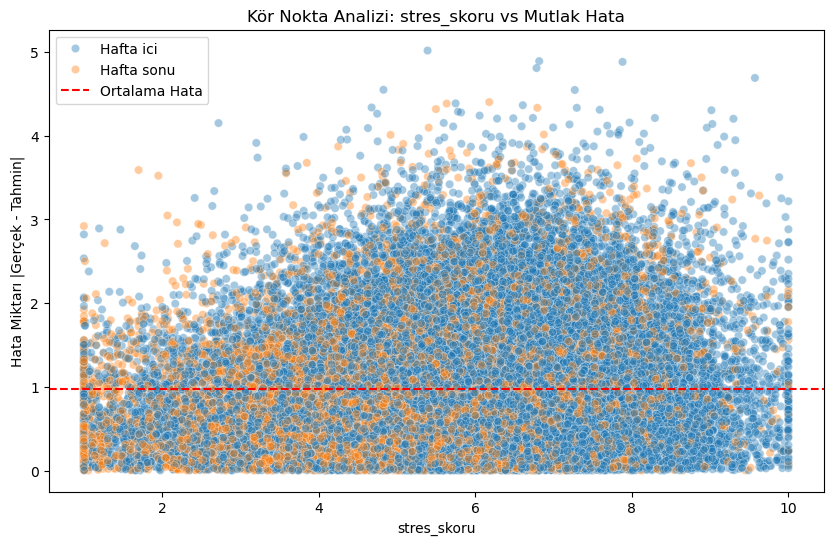


--- EN YÜKSEK %5 HATAYA SAHİP PROFİLLER ---
Hatalı Meslekler:
 meslek
Saglik Personeli     642
Ogrenci              469
Muhendis             331
Lojistik Calisani    240
Yonetici             224
Name: count, dtype: int64

Hatalı Gün Tipleri:
 gun_tipi
Hafta ici     2236
Hafta sonu     564
Name: count, dtype: int64

Hatalı Kronotipler:
 kronotip
Notr            1189
Gece insani      813
Sabah insani     709
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance için hızlıca bir model daha fit ediyoruz
full_pool = Pool(X, y, cat_features=cat_features)
final_model = CatBoostRegressor(iterations=100, depth=5, verbose=0).fit(full_pool)

importances = final_model.get_feature_importance()
imp_df = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values(by='importance', ascending=False)
top_numeric_feature = imp_df[imp_df['feature'].isin(X.select_dtypes(include=[np.number]).columns)].iloc[0]['feature']

print(f"Model için en önemli sayısal özellik: {top_numeric_feature}")

# 1. GÖRSEL: Hata Dağılımı (Scatter)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train[top_numeric_feature], y=train['mutlak_hata'], alpha=0.4, hue=train['gun_tipi'])
plt.title(f'Kör Nokta Analizi: {top_numeric_feature} vs Mutlak Hata')
plt.xlabel(top_numeric_feature)
plt.ylabel('Hata Miktarı |Gerçek - Tahmin|')
plt.axhline(y=train['mutlak_hata'].mean(), color='r', linestyle='--', label='Ortalama Hata')
plt.legend()
plt.show()

# 2. KARANLIK BÖLGE: Hatası en yüksek %5'lik kesim
threshold = train['mutlak_hata'].quantile(0.95)
karanlik_bolge = train[train['mutlak_hata'] >= threshold]

print("\n--- EN YÜKSEK %5 HATAYA SAHİP PROFİLLER ---")
print("Hatalı Meslekler:\n", karanlik_bolge['meslek'].value_counts().head())
print("\nHatalı Gün Tipleri:\n", karanlik_bolge['gun_tipi'].value_counts())
print("\nHatalı Kronotipler:\n", karanlik_bolge['kronotip'].value_counts())

In [15]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold

print(" Saf ve Temiz Veriler Yükleniyor...")
# O iki zararlı özelliği sildik. Sadece orijinal veriyi okuyoruz.
train = pd.read_csv('train.csv')
test = pd.read_csv('test_x.csv') 

# X, y ve test hazırlığı
X = train.drop(['id', 'bilissel_performans_skoru'], axis=1, errors='ignore')
y = train['bilissel_performans_skoru']
X_test = test.drop(['id'], axis=1, errors='ignore')

# Kategorik sütunları bulma
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("bulunuyor")
# Kategorikleri metne çevirip NaN'ları dolduruyoruz
X[cat_features] = X[cat_features].fillna('Bilinmiyor').astype(str)
X_test[cat_features] = X_test[cat_features].fillna('Bilinmiyor').astype(str)

# 3 Farklı Rastgelelik ile Öğrenme (Seed Averaging)
seeds = [42, 1923, 2024]
final_test_preds = np.zeros(len(X_test))

print("Model Eğitimi Başlıyor (Seed Averaging)...")

for seed in seeds:
    print(f"\n--- Seed {seed} Döngüsü ---")
    # cat_params'ın daha önce tanımlı olduğunu varsayıyoruz (1500 iterasyonluk diyet hali)
    current_params = cat_params.copy()
    current_params['random_seed'] = seed
    
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    seed_preds = np.zeros(len(X_test))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        val_pool = Pool(X_va, y_va, cat_features=cat_features)
        test_pool = Pool(X_test, cat_features=cat_features)

        model = CatBoostRegressor(**current_params)
        model.fit(train_pool, eval_set=val_pool, verbose=0)
        
        seed_preds += model.predict(test_pool) / kf.n_splits
        print(f"  Fold {fold+1} tamamlandı.")
        
    final_test_preds += seed_preds / len(seeds)

print("\n✅ Tüm modeller eğitildi ve tahminler birleştirildi!")

print("3. Kesin Güvenlik Kilidi (Clipping)...")
# RMSE'yi patlatan sınır dışı değerleri buduyoruz
final_test_preds_clipped = np.clip(final_test_preds, 0.0, 10.0)

# SUBMISSION DOSYASINI OLUŞTURMA
submission_df = pd.DataFrame({
    'id': test['id'],
    'bilissel_performans_skoru': final_test_preds_clipped
})

file_name = 'SUBMISSION.csv'
submission_df.to_csv(file_name, index=False)
print(f"🏆 {file_name} dosyası kaydedildi! Kaggle'a yüklemeye hazır.")

1. Saf ve Temiz Veriler Yükleniyor (Geri Dönüş)...
2. Zırh Takılıyor (Eksik Veri ve Tip Zorlaması)...
🚀 Güvenli Liman Modeli Eğitimi Başlıyor (Seed Averaging)...

--- Seed 42 Döngüsü ---
  Fold 1 tamamlandı.
  Fold 2 tamamlandı.
  Fold 3 tamamlandı.
  Fold 4 tamamlandı.
  Fold 5 tamamlandı.

--- Seed 1923 Döngüsü ---
  Fold 1 tamamlandı.
  Fold 2 tamamlandı.
  Fold 3 tamamlandı.
  Fold 4 tamamlandı.
  Fold 5 tamamlandı.

--- Seed 2024 Döngüsü ---
  Fold 1 tamamlandı.
  Fold 2 tamamlandı.
  Fold 3 tamamlandı.
  Fold 4 tamamlandı.
  Fold 5 tamamlandı.

✅ Tüm modeller eğitildi ve tahminler birleştirildi!
3. Kesin Güvenlik Kilidi (Clipping)...
🏆 HILAL_GUVENLI_LIMAN_SUBMISSION.csv dosyası kaydedildi! Kaggle'a yüklemeye hazır.


In [16]:
train[['id', 'bilissel_performans_skoru']].corr()

,id,bilissel_performans_skoru
id,1.000000,-0.005845
bilissel_performans_skoru,-0.005845,1.000000
